In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from collections import defaultdict, deque
from copy import deepcopy


In [109]:
df = pd.read_csv('premier_league.csv')
dp = pd.read_csv('2016-17.csv')

In [110]:
dp.head()

,Season,Date,Time,Round,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR,Venue,City,Attendance,Referee
0,2016-17,2016-08-13,12:30,1,Hull,Leicester City,2,1,1.0,0.0,H,NaN,NaN,NaN,NaN
1,2016-17,2016-08-13,15:00,1,Burnley,Swansea,0,1,0.0,0.0,A,NaN,NaN,NaN,NaN
2,2016-17,2016-08-13,NaN,1,Crystal Palace,West Bromwich Albion,0,1,0.0,0.0,A,NaN,NaN,NaN,NaN
3,2016-17,2016-08-13,NaN,1,Everton,Tottenham Hotspur,1,1,1.0,0.0,D,NaN,NaN,NaN,NaN
4,2016-17,2016-08-13,NaN,1,Middlesbrough,Stoke City,1,1,1.0,0.0,D,NaN,NaN,NaN,NaN


In [111]:
df.head()

,Season,Date,Time,Round,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR,Venue,City,Attendance,Referee
0,2017-18,2017-08-11,19:45,1,Arsenal,Leicester City,4,3,2.0,2.0,H,NaN,NaN,NaN,NaN
1,2017-18,2017-08-12,12:30,1,Watford,Liverpool,3,3,2.0,1.0,D,NaN,NaN,NaN,NaN
2,2017-18,2017-08-12,15:00,1,Chelsea,Burnley,2,3,0.0,3.0,A,NaN,NaN,NaN,NaN
3,2017-18,2017-08-12,NaN,1,Crystal Palace,Huddersfield Town,0,3,0.0,2.0,A,NaN,NaN,NaN,NaN
4,2017-18,2017-08-12,NaN,1,Everton,Stoke City,1,0,1.0,0.0,H,NaN,NaN,NaN,NaN


In [112]:
df.shape

(3420, 15)

In [113]:
df.isnull().sum()

,0
Season,0
Date,0
Time,1085
Round,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
HTHG,177
HTAG,177


In [114]:
df = df.drop(columns = ['Venue', 'City', 'Attendance', 'Referee', 'HTHG', 'HTAG', 'Time'])
dp = dp.drop(columns = ['Venue', 'City', 'Attendance', 'Referee', 'HTHG', 'HTAG', 'Time'])

In [115]:
dp.isnull().sum()

,0
Season,0
Date,0
Round,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
FTR,0


In [116]:
df.isnull().sum()

,0
Season,0
Date,0
Round,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
FTR,0


In [117]:
df = df.rename(columns={
    "FTHG": "Full Time Home Goals",
    "FTAG": "Full Time Away Goals",
    "HTHG": "Half Time Home Goals",
    "HTAG": "Half Time Away Goals",
    "FTR": "Full Time Result"
})


dp = dp.rename(columns={
    "FTHG": "Full Time Home Goals",
    "FTAG": "Full Time Away Goals",
    "HTHG": "Half Time Home Goals",
    "HTAG": "Half Time Away Goals",
    "FTR": "Full Time Result"
})

In [118]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [119]:
dp["Date"] = pd.to_datetime(dp["Date"])
dp = dp.sort_values("Date").reset_index(drop=True)

In [120]:
# ==========================================
# CREATE FEATURES
# ==========================================

df["Home_Avg_Goals_Scored"] = 0.0
df["Home_Avg_Goals_Conceded"] = 0.0
df["Home_Last5_Wins"] = 0
df["Home_Last5_Draws"] = 0
df["Home_Last5_Losses"] = 0

df["Away_Avg_Goals_Scored"] = 0.0
df["Away_Avg_Goals_Conceded"] = 0.0
df["Away_Last5_Wins"] = 0
df["Away_Last5_Draws"] = 0
df["Away_Last5_Losses"] = 0

df["H2H_Home_Wins"] = 0
df["H2H_Draws"] = 0
df["H2H_Away_Wins"] = 0


# ==========================================
# CURRENT SEASON GOAL STATISTICS
# ==========================================

season_stats = defaultdict(lambda: {
    "goals_scored": 0,
    "goals_conceded": 0,
    "matches": 0
})


# ==========================================
# LAST 5 MATCHES
# CONTINUES ACROSS SEASONS
# ==========================================

last5 = defaultdict(lambda: deque(maxlen=5))


# ==========================================
# PREVIOUS SEASON STATISTICS
# ==========================================

previous_season_stats = defaultdict(lambda: {
    "goals_scored": 0,
    "goals_conceded": 0,
    "matches": 0
})


# ==========================================
# HEAD-TO-HEAD HISTORY
# ==========================================

h2h = defaultdict(lambda: {
    "home_wins": 0,
    "draws": 0,
    "away_wins": 0
})


# ==========================================
# USE 2016-17 AS INITIAL HISTORY
# ==========================================

for _, row in dp.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]

    home_goals = row["Full Time Home Goals"]
    away_goals = row["Full Time Away Goals"]


    # ------------------------------------------
    # GOAL STATISTICS
    # ------------------------------------------

    previous_season_stats[home]["goals_scored"] += home_goals
    previous_season_stats[home]["goals_conceded"] += away_goals
    previous_season_stats[home]["matches"] += 1

    previous_season_stats[away]["goals_scored"] += away_goals
    previous_season_stats[away]["goals_conceded"] += home_goals
    previous_season_stats[away]["matches"] += 1


    # ------------------------------------------
    # LAST 5 RESULTS
    # ------------------------------------------

    if home_goals > away_goals:

        last5[home].append("W")
        last5[away].append("L")

    elif home_goals < away_goals:

        last5[home].append("L")
        last5[away].append("W")

    else:

        last5[home].append("D")
        last5[away].append("D")


    # ------------------------------------------
    # H2H HISTORY
    # ------------------------------------------

    if home_goals > away_goals:

        h2h[(home, away)]["home_wins"] += 1

    elif home_goals < away_goals:

        h2h[(home, away)]["away_wins"] += 1

    else:

        h2h[(home, away)]["draws"] += 1


# ==========================================
# PROCESS MAIN DATASET
# 2017-18 → 2024-25
# ==========================================

current_season = None


for i, row in df.iterrows():

    season = row["Season"]

    home = row["HomeTeam"]
    away = row["AwayTeam"]


    # ==========================================
    # NEW SEASON
    # ==========================================

    if season != current_season:

        # Save previous season's statistics
        if current_season is not None:
            previous_season_stats = deepcopy(season_stats)


        # Reset ONLY goal statistics
        season_stats = defaultdict(lambda: {
            "goals_scored": 0,
            "goals_conceded": 0,
            "matches": 0
        })

        current_season = season


    h = season_stats[home]
    a = season_stats[away]


    # ==========================================
    # HOME TEAM GOAL AVERAGES
    # ==========================================

    # First 5 matches of the season
    if h["matches"] < 5:

        previous = previous_season_stats[home]

        total_scored = (
            previous["goals_scored"] +
            h["goals_scored"]
        )

        total_conceded = (
            previous["goals_conceded"] +
            h["goals_conceded"]
        )

        total_matches = (
            previous["matches"] +
            h["matches"]
        )

        if total_matches > 0:

            df.loc[i, "Home_Avg_Goals_Scored"] = (
                total_scored / total_matches
            )

            df.loc[i, "Home_Avg_Goals_Conceded"] = (
                total_conceded / total_matches
            )


    # From match 6 onward → current season only
    else:

        df.loc[i, "Home_Avg_Goals_Scored"] = (
            h["goals_scored"] / h["matches"]
        )

        df.loc[i, "Home_Avg_Goals_Conceded"] = (
            h["goals_conceded"] / h["matches"]
        )


    # ==========================================
    # AWAY TEAM GOAL AVERAGES
    # ==========================================

    # First 5 matches of the season
    if a["matches"] < 5:

        previous = previous_season_stats[away]

        total_scored = (
            previous["goals_scored"] +
            a["goals_scored"]
        )

        total_conceded = (
            previous["goals_conceded"] +
            a["goals_conceded"]
        )

        total_matches = (
            previous["matches"] +
            a["matches"]
        )

        if total_matches > 0:

            df.loc[i, "Away_Avg_Goals_Scored"] = (
                total_scored / total_matches
            )

            df.loc[i, "Away_Avg_Goals_Conceded"] = (
                total_conceded / total_matches
            )


    # From match 6 onward → current season only
    else:

        df.loc[i, "Away_Avg_Goals_Scored"] = (
            a["goals_scored"] / a["matches"]
        )

        df.loc[i, "Away_Avg_Goals_Conceded"] = (
            a["goals_conceded"] / a["matches"]
        )


    # ==========================================
    # LAST 5 RESULTS
    # OVERALL, ACROSS SEASONS
    # ==========================================

    df.loc[i, "Home_Last5_Wins"] = last5[home].count("W")
    df.loc[i, "Home_Last5_Draws"] = last5[home].count("D")
    df.loc[i, "Home_Last5_Losses"] = last5[home].count("L")

    df.loc[i, "Away_Last5_Wins"] = last5[away].count("W")
    df.loc[i, "Away_Last5_Draws"] = last5[away].count("D")
    df.loc[i, "Away_Last5_Losses"] = last5[away].count("L")


    # ==========================================
    # HEAD-TO-HEAD
    # BEFORE CURRENT MATCH
    # ==========================================

    if (home, away) in h2h:

        df.loc[i, "H2H_Home_Wins"] = (
            h2h[(home, away)]["home_wins"]
        )

        df.loc[i, "H2H_Draws"] = (
            h2h[(home, away)]["draws"]
        )

        df.loc[i, "H2H_Away_Wins"] = (
            h2h[(home, away)]["away_wins"]
        )

    elif (away, home) in h2h:

        df.loc[i, "H2H_Home_Wins"] = (
            h2h[(away, home)]["away_wins"]
        )

        df.loc[i, "H2H_Draws"] = (
            h2h[(away, home)]["draws"]
        )

        df.loc[i, "H2H_Away_Wins"] = (
            h2h[(away, home)]["home_wins"]
        )


    # ==========================================
    # UPDATE STATISTICS AFTER THE MATCH
    # ==========================================

    home_goals = row["Full Time Home Goals"]
    away_goals = row["Full Time Away Goals"]


    # ------------------------------------------
    # UPDATE GOAL STATISTICS
    # ------------------------------------------

    h["goals_scored"] += home_goals
    h["goals_conceded"] += away_goals
    h["matches"] += 1

    a["goals_scored"] += away_goals
    a["goals_conceded"] += home_goals
    a["matches"] += 1


    # ------------------------------------------
    # UPDATE LAST 5 QUEUE
    # ------------------------------------------

    if home_goals > away_goals:

        last5[home].append("W")
        last5[away].append("L")

    elif home_goals < away_goals:

        last5[home].append("L")
        last5[away].append("W")

    else:

        last5[home].append("D")
        last5[away].append("D")


    # ------------------------------------------
    # UPDATE H2H
    # ------------------------------------------

    if home_goals > away_goals:

        h2h[(home, away)]["home_wins"] += 1

    elif home_goals < away_goals:

        h2h[(home, away)]["away_wins"] += 1

    else:

        h2h[(home, away)]["draws"] += 1

In [121]:
df.head()

,Season,Date,Round,HomeTeam,AwayTeam,Full Time Home Goals,Full Time Away Goals,Full Time Result,Home_Avg_Goals_Scored,Home_Avg_Goals_Conceded,...,Home_Last5_Draws,Home_Last5_Losses,Away_Avg_Goals_Scored,Away_Avg_Goals_Conceded,Away_Last5_Wins,Away_Last5_Draws,Away_Last5_Losses,H2H_Home_Wins,H2H_Draws,H2H_Away_Wins
0,2017-18,2017-08-11,1,Arsenal,Leicester City,4,3,H,2.026316,1.157895,...,0,0,1.263158,1.657895,2,1,2,1,0,0
1,2017-18,2017-08-12,1,Watford,Liverpool,3,3,D,1.052632,1.789474,...,0,5,2.052632,1.105263,3,1,1,0,0,1
2,2017-18,2017-08-12,1,Chelsea,Burnley,2,3,A,0.000000,0.000000,...,0,0,1.026316,1.447368,1,1,3,0,0,0
3,2017-18,2017-08-12,1,Crystal Palace,Huddersfield Town,0,3,A,1.315789,1.657895,...,0,4,0.000000,0.000000,0,0,0,0,0,0
4,2017-18,2017-08-12,1,Everton,Stoke City,1,0,H,1.631579,1.157895,...,1,3,1.078947,1.473684,1,2,2,1,0,0


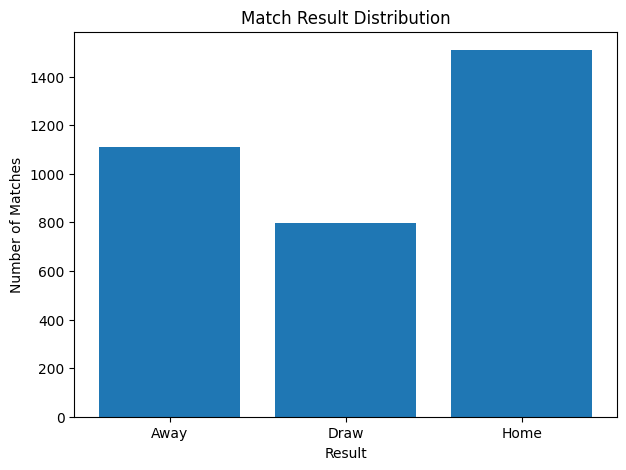

In [122]:
result_counts = df["Full Time Result"].value_counts().sort_index()

labels = ["Away", "Draw", "Home"]

plt.figure(figsize=(7, 5))

plt.bar(labels, result_counts.values)

plt.title("Match Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")

plt.show()

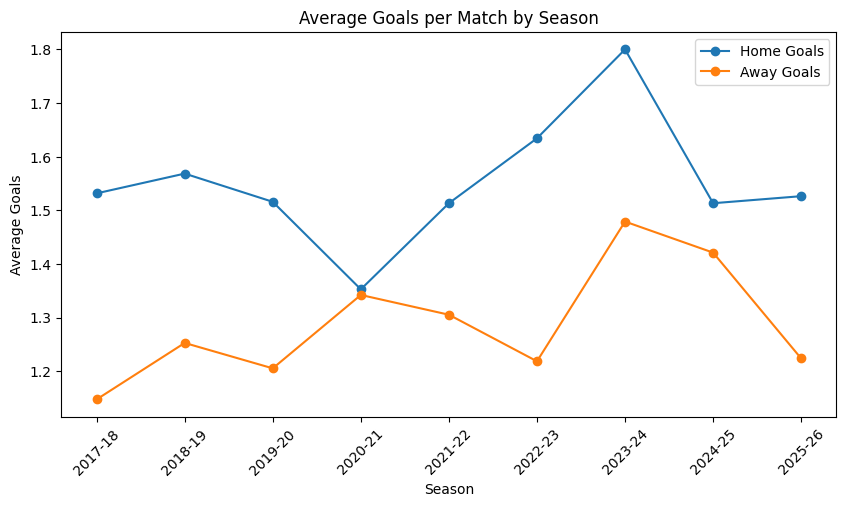

In [123]:
season_goals = df.groupby("Season")[
    ["Full Time Home Goals", "Full Time Away Goals"]
].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    season_goals.index,
    season_goals["Full Time Home Goals"],
    marker="o",
    label="Home Goals"
)

plt.plot(
    season_goals.index,
    season_goals["Full Time Away Goals"],
    marker="o",
    label="Away Goals"
)

plt.title("Average Goals per Match by Season")
plt.xlabel("Season")
plt.ylabel("Average Goals")
plt.xticks(rotation=45)
plt.legend()

plt.show()

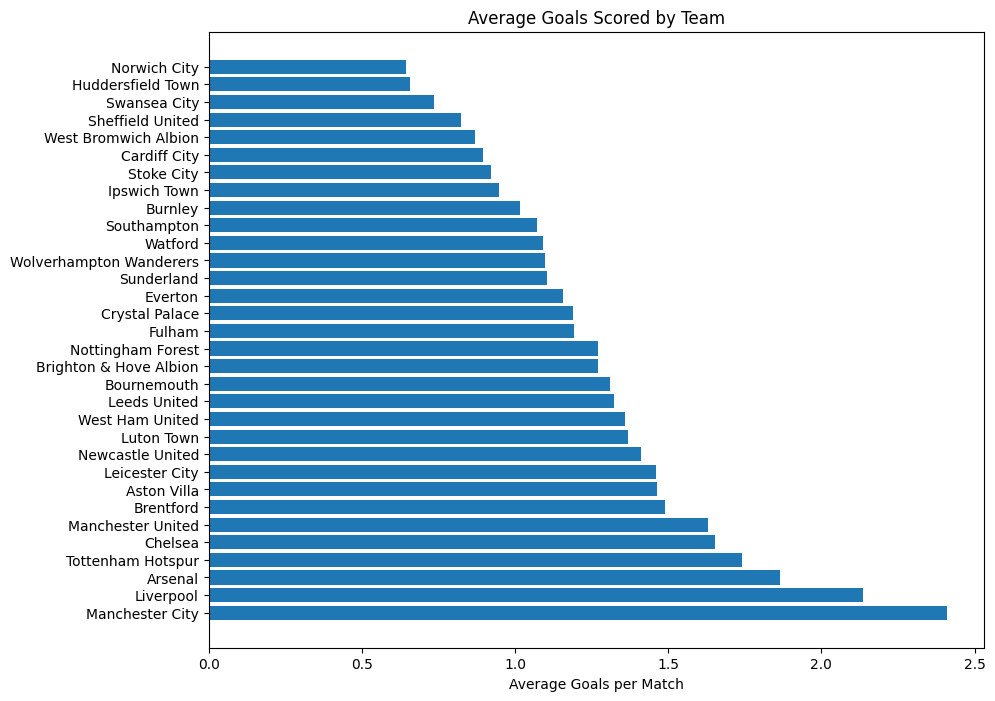

In [124]:
team_goals = defaultdict(float)
team_matches = defaultdict(int)

for _, row in df.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]

    team_goals[home] += row["Full Time Home Goals"]
    team_goals[away] += row["Full Time Away Goals"]

    team_matches[home] += 1
    team_matches[away] += 1

team_avg_goals = {
    team: team_goals[team] / team_matches[team]
    for team in team_goals
}

team_avg_goals = pd.Series(team_avg_goals).sort_values(ascending=False)

plt.figure(figsize=(10, 8))

plt.barh(
    team_avg_goals.index,
    team_avg_goals.values
)

plt.title("Average Goals Scored by Team")
plt.xlabel("Average Goals per Match")

plt.show()

In [125]:
features = [

    "Home_Avg_Goals_Scored",
    "Home_Avg_Goals_Conceded",
    "Home_Last5_Wins",
    "Home_Last5_Draws",
    "Home_Last5_Losses",
    "Away_Avg_Goals_Scored",
    "Away_Avg_Goals_Conceded",
    "Away_Last5_Wins",
    "Away_Last5_Draws",
    "Away_Last5_Losses",
    "H2H_Home_Wins",
    "H2H_Draws",
    "H2H_Away_Wins"
]



In [126]:
df[features].describe()

,Home_Avg_Goals_Scored,Home_Avg_Goals_Conceded,Home_Last5_Wins,Home_Last5_Draws,Home_Last5_Losses,Away_Avg_Goals_Scored,Away_Avg_Goals_Conceded,Away_Last5_Wins,Away_Last5_Draws,Away_Last5_Losses,H2H_Home_Wins,H2H_Draws,H2H_Away_Wins
count,3420.000000,3420.000000,3420.000000,3420.000000,3420.000000,3420.000000,3420.000000,3420.00000,3420.000000,3420.000000,3420.000000,3420.000000,3420.000000
mean,1.406916,1.412057,1.874561,1.152339,1.935380,1.421928,1.407253,1.95000,1.155848,1.857310,1.340058,0.688012,0.935380
std,0.542280,0.449913,1.261761,0.941337,1.242317,0.541551,0.438298,1.26815,0.953118,1.237794,1.531717,0.951302,1.228586
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.147059,1.000000,0.000000,1.000000,1.000000,1.148148,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.341463,1.400000,2.000000,1.000000,2.000000,1.352941,1.390774,2.00000,1.000000,2.000000,1.000000,0.000000,1.000000
75%,1.750000,1.675000,3.000000,2.000000,3.000000,1.750000,1.666667,3.00000,2.000000,3.000000,2.000000,1.000000,1.000000
max,3.857143,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.00000,5.000000,5.000000,9.000000,6.000000,8.000000


In [127]:
encoder = LabelEncoder()
df['Full Time Result'] = encoder.fit_transform(df['Full Time Result'])

In [128]:
X = df[features]
y = df["Full Time Result"]

In [129]:
seasons = sorted(df["Season"].unique())

for i in range(1, len(seasons)):

    train_seasons = seasons[:i]
    test_season = seasons[i]

    train = df[df["Season"].isin(train_seasons)]
    test = df[df["Season"] == test_season]

    X_train = train[features]
    y_train = train["Full Time Result"]

    X_test = test[features]
    y_test = test["Full Time Result"]

    print(f"Fold {i}")
    print("Train:", train_seasons)
    print("Test :", test_season)
    print("Train size:", len(X_train))
    print("Test size :", len(X_test))
    print()

Fold 1
Train: ['2017-18']
Test : 2018-19
Train size: 380
Test size : 380

Fold 2
Train: ['2017-18', '2018-19']
Test : 2019-20
Train size: 760
Test size : 380

Fold 3
Train: ['2017-18', '2018-19', '2019-20']
Test : 2020-21
Train size: 1140
Test size : 380

Fold 4
Train: ['2017-18', '2018-19', '2019-20', '2020-21']
Test : 2021-22
Train size: 1520
Test size : 380

Fold 5
Train: ['2017-18', '2018-19', '2019-20', '2020-21', '2021-22']
Test : 2022-23
Train size: 1900
Test size : 380

Fold 6
Train: ['2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
Test : 2023-24
Train size: 2280
Test size : 380

Fold 7
Train: ['2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']
Test : 2024-25
Train size: 2660
Test size : 380

Fold 8
Train: ['2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
Test : 2025-26
Train size: 3040
Test size : 380



In [130]:
######################################################################

In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

seasons = sorted(df["Season"].unique())

accuracies = []

for i in range(1, len(seasons)):

    train_seasons = seasons[:i]
    test_season = seasons[i]

    train = df[df["Season"].isin(train_seasons)]
    test = df[df["Season"] == test_season]

    X_train = train[features]
    y_train = train["Full Time Result"]

    X_test = test[features]
    y_test = test["Full Time Result"]

    model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print(f"{test_season}: {accuracy:.4f}")

print(f"\nAverage Accuracy: {sum(accuracies) / len(accuracies):.4f}")

2018-19: 0.5158
2019-20: 0.5105
2020-21: 0.4368
2021-22: 0.4816
2022-23: 0.4842
2023-24: 0.5579
2024-25: 0.4947
2025-26: 0.4579

Average Accuracy: 0.4924


In [132]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

seasons = sorted(df["Season"].unique())

accuracies = []

for i in range(1, len(seasons)):

    train_seasons = seasons[:i]
    test_season = seasons[i]

    train = df[df["Season"].isin(train_seasons)]
    test = df[df["Season"] == test_season]

    X_train = train[features]
    y_train = train["Full Time Result"]

    X_test = test[features]
    y_test = test["Full Time Result"]

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        eval_metric="mlogloss"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    print(f"{test_season}: {accuracy * 100:.2f}%")

print("\nOverall CV Accuracy:")
print(f"{sum(accuracies) / len(accuracies) * 100:.2f}%")

2018-19: 53.68%
2019-20: 50.00%
2020-21: 47.89%
2021-22: 51.05%
2022-23: 53.16%
2023-24: 57.63%
2024-25: 50.26%
2025-26: 49.47%

Overall CV Accuracy:
51.64%


In [133]:
X = df[features]
y = df["Full Time Result"]
model = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=1.0, colsample_bytree=1.0,
    random_state=42, eval_metric="mlogloss"
)
model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [134]:
from collections import defaultdict, deque

team_stats = defaultdict(lambda: {
    "goals_scored": [],
    "goals_conceded": []
})

last5 = defaultdict(lambda: deque(maxlen=5))

h2h = defaultdict(lambda: {
    "home_wins": 0,
    "draws": 0,
    "away_wins": 0
})

for _, row in df.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]

    home_goals = row["Full Time Home Goals"]
    away_goals = row["Full Time Away Goals"]

    # Goal statistics
    team_stats[home]["goals_scored"].append(home_goals)
    team_stats[home]["goals_conceded"].append(away_goals)

    team_stats[away]["goals_scored"].append(away_goals)
    team_stats[away]["goals_conceded"].append(home_goals)

    # Last 5 form
    if home_goals > away_goals:
        last5[home].append("W")
        last5[away].append("L")

    elif home_goals < away_goals:
        last5[home].append("L")
        last5[away].append("W")

    else:
        last5[home].append("D")
        last5[away].append("D")

    # H2H
    if home_goals > away_goals:
        h2h[(home, away)]["home_wins"] += 1

    elif home_goals < away_goals:
        h2h[(home, away)]["away_wins"] += 1

    else:
        h2h[(home, away)]["draws"] += 1

In [135]:
def predict_match(home_team, away_team):

    home_avg_scored = sum(team_stats[home_team]["goals_scored"]) / len(
        team_stats[home_team]["goals_scored"]
    )

    home_avg_conceded = sum(team_stats[home_team]["goals_conceded"]) / len(
        team_stats[home_team]["goals_conceded"]
    )

    away_avg_scored = sum(team_stats[away_team]["goals_scored"]) / len(
        team_stats[away_team]["goals_scored"]
    )

    away_avg_conceded = sum(team_stats[away_team]["goals_conceded"]) / len(
        team_stats[away_team]["goals_conceded"]
    )

    home_last5 = last5[home_team]
    away_last5 = last5[away_team]

    home_wins = home_last5.count("W")
    home_draws = home_last5.count("D")
    home_losses = home_last5.count("L")

    away_wins = away_last5.count("W")
    away_draws = away_last5.count("D")
    away_losses = away_last5.count("L")

    h2h_home_wins = 0
    h2h_draws = 0
    h2h_away_wins = 0

    if (home_team, away_team) in h2h:

        h2h_home_wins = h2h[(home_team, away_team)]["home_wins"]
        h2h_draws = h2h[(home_team, away_team)]["draws"]
        h2h_away_wins = h2h[(home_team, away_team)]["away_wins"]

    elif (away_team, home_team) in h2h:

        h2h_home_wins = h2h[(away_team, home_team)]["away_wins"]
        h2h_draws = h2h[(away_team, home_team)]["draws"]
        h2h_away_wins = h2h[(away_team, home_team)]["home_wins"]

    X = pd.DataFrame([[
        home_avg_scored,
        home_avg_conceded,
        home_wins,
        home_draws,
        home_losses,
        away_avg_scored,
        away_avg_conceded,
        away_wins,
        away_draws,
        away_losses,
        h2h_home_wins,
        h2h_draws,
        h2h_away_wins
    ]], columns=features)

    probabilities = model.predict_proba(X)[0]

    return {
        "home_win": probabilities[2],
        "draw": probabilities[1],
        "away_win": probabilities[0]
    }

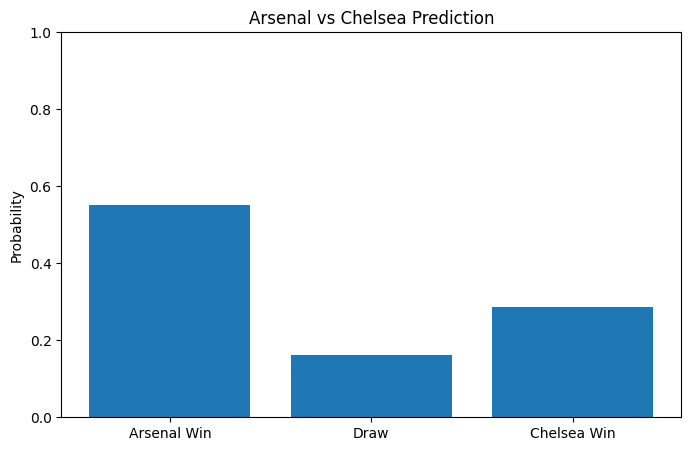

In [136]:
result = predict_match("Arsenal", "Chelsea")

labels = ["Arsenal Win", "Draw", "Chelsea Win"]

values = [
    result["home_win"],
    result["draw"],
    result["away_win"]
]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.title("Arsenal vs Chelsea Prediction")
plt.ylabel("Probability")

plt.ylim(0, 1)

plt.show()

In [137]:
teams = sorted(set(df["HomeTeam"]) | set(df["AwayTeam"]))

print(teams)

['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton & Hove Albion', 'Burnley', 'Cardiff City', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Huddersfield Town', 'Ipswich Town', 'Leeds United', 'Leicester City', 'Liverpool', 'Luton Town', 'Manchester City', 'Manchester United', 'Newcastle United', 'Norwich City', 'Nottingham Forest', 'Sheffield United', 'Southampton', 'Stoke City', 'Sunderland', 'Swansea City', 'Tottenham Hotspur', 'Watford', 'West Bromwich Albion', 'West Ham United', 'Wolverhampton Wanderers']


In [138]:
result = predict_match("Arsenal", "Manchester City")

print(result)

{'home_win': np.float32(0.2850928), 'draw': np.float32(0.2414131), 'away_win': np.float32(0.4734941)}


Home_Avg_Goals_Scored      0.176075
Away_Avg_Goals_Scored      0.147723
Away_Avg_Goals_Conceded    0.091549
H2H_Away_Wins              0.087815
Home_Last5_Wins            0.070815
Home_Last5_Losses          0.069568
Home_Avg_Goals_Conceded    0.064156
Away_Last5_Wins            0.057078
H2H_Draws                  0.053998
Away_Last5_Losses          0.050316
H2H_Home_Wins              0.046513
Away_Last5_Draws           0.042713
Home_Last5_Draws           0.041680
dtype: float32


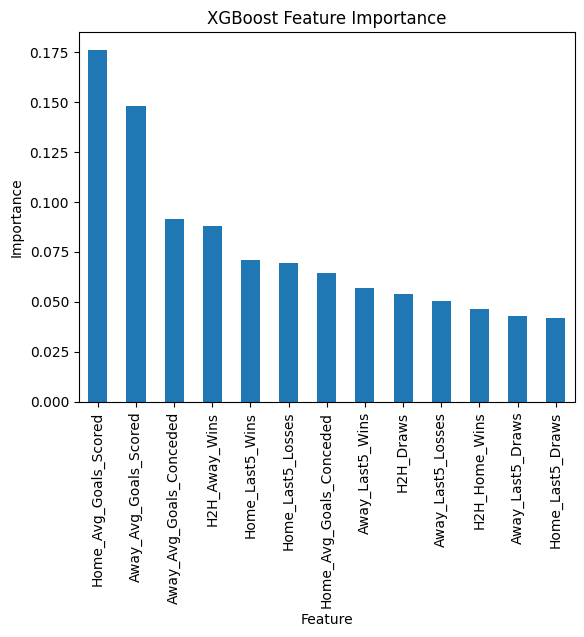

In [139]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

importance.plot(kind="bar")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()

In [140]:
import gradio as gr

teams = sorted(set(df["HomeTeam"]) | set(df["AwayTeam"]))


def predict_for_gui(home_team, away_team):

    if home_team == away_team:
        return "<div class='placeholder'>Please select two different teams.</div>"

    result = predict_match(home_team, away_team)

    outcomes = [
        (home_team, result["home_win"] * 100),
        ("Draw", result["draw"] * 100),
        (away_team, result["away_win"] * 100),
    ]

    best_label = max(outcomes, key=lambda x: x[1])[0]

    rows = ""
    for label, pct in outcomes:
        is_best = "highlight" if label == best_label else ""
        rows += f"""
        <div class="outcome-row {is_best}">
            <div class="outcome-label">{label}</div>
            <div class="bar-track">
                <div class="bar-fill {is_best}" style="width:{pct:.1f}%;"></div>
            </div>
            <div class="outcome-pct">{pct:.1f}%</div>
        </div>
        """

    return f"""
    <div class='result-box'>
        <div class='favored-tag'>Most Likely: <strong>{best_label}</strong></div>
        {rows}
    </div>
    """


css = """
body {
    background: white;
}

#title {
    text-align: center;
    font-size: 42px;
    font-weight: bold;
    color: #1565c0;
}

#subtitle {
    text-align: center;
    font-size: 20px;
    color: #555;
}

.team-dropdown {
    font-size: 20px !important;
}

#predict-button {
    font-size: 24px !important;
    font-weight: bold;
    height: 65px;
    background: #1565c0 !important;
    color: white !important;
}

.result-box {
    margin-top: 25px;
    padding: 30px;
    border: 2px solid #1565c0;
    border-radius: 15px;
    background: #f5f9ff;
}

.placeholder {
    margin-top: 25px;
    padding: 30px;
    text-align: center;
    font-size: 18px;
    color: #888;
    border: 2px dashed #ccc;
    border-radius: 15px;
}

.favored-tag {
    text-align: center;
    font-size: 20px;
    color: #555;
    margin-bottom: 25px;
}

.favored-tag strong {
    color: #0d47a1;
}

.outcome-row {
    display: flex;
    align-items: center;
    gap: 15px;
    margin-bottom: 18px;
}

.outcome-label {
    min-width: 140px;
    font-size: 18px;
    font-weight: bold;
    color: #1565c0;
    text-align: right;
}

.bar-track {
    flex: 1;
    height: 28px;
    background: #e3ecf7;
    border-radius: 14px;
    overflow: hidden;
}

.bar-fill {
    height: 100%;
    background: #90a4c4;
    border-radius: 14px;
}

.bar-fill.highlight {
    background: #1565c0;
}

.outcome-row.highlight .outcome-label {
    color: #0d47a1;
}

.outcome-pct {
    min-width: 60px;
    font-size: 18px;
    font-weight: bold;
    color: #333;
}

.outcome-row.highlight .outcome-pct {
    color: #0d47a1;
    font-size: 20px;
}


/* ============================= */
/* MOBILE                        */
/* ============================= */

@media (max-width: 600px) {

    #title {
        font-size: 28px;
        line-height: 1.2;
    }

    #subtitle {
        font-size: 15px;
        line-height: 1.4;
        padding: 0 10px;
    }

    .team-dropdown {
        font-size: 16px !important;
    }

    #predict-button {
        font-size: 19px !important;
        height: 55px;
    }

    .result-box {
        padding: 20px;
    }

    .outcome-label {
        min-width: 90px;
        font-size: 14px;
    }

    .outcome-pct {
        min-width: 45px;
        font-size: 14px;
    }

    .bar-track {
        height: 22px;
    }
}
"""


with gr.Blocks(title="Premier League Match Predictor") as demo:

    gr.Markdown(
        "# ⚽ Premier League Match Predictor",
        elem_id="title"
    )

    gr.Markdown(
        "Predict the outcome of a Premier League match using Machine Learning",
        elem_id="subtitle"
    )

    with gr.Row():

        home_team = gr.Dropdown(
            choices=teams,
            label="HOME TEAM",
            value="Chelsea",
            elem_classes="team-dropdown"
        )

        away_team = gr.Dropdown(
            choices=teams,
            label="AWAY TEAM",
            value="Fulham",
            elem_classes="team-dropdown"
        )

    predict_button = gr.Button(
        "⚽ PREDICT MATCH",
        variant="primary",
        elem_id="predict-button"
    )

    prediction = gr.HTML(
        value="<div class='placeholder'>Select two teams and click Predict to see the odds.</div>"
    )

    predict_button.click(
        fn=predict_for_gui,
        inputs=[home_team, away_team],
        outputs=prediction
    )


demo.launch(css=css)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://30bd525b47e15e5ee0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
